In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║                  Feature Engineering                     ║
# ╚══════════════════════════════════════════════════════════╝

In [10]:
# ── Imports Libraries ───────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# ── Load Raw Data ─────────────────────────────────
df = pd.read_csv("../dataset/cleaned/housing_cleaned.csv")
df.head(10)

,City,Price,Number_Beds,Number_Baths,Province,Population,Latitude,Longitude,Median_Family_Income
0,Toronto,779900.0,3.0,2.0,Ontario,5647656,43.7417,-79.3733,97000.0
1,Toronto,799999.0,3.0,1.0,Ontario,5647656,43.7417,-79.3733,97000.0
2,Toronto,799900.0,2.0,2.0,Ontario,5647656,43.7417,-79.3733,97000.0
3,Toronto,1200000.0,4.0,2.0,Ontario,5647656,43.7417,-79.3733,97000.0
4,Toronto,668800.0,1.0,1.0,Ontario,5647656,43.7417,-79.3733,97000.0
5,Toronto,548000.0,2.0,1.0,Ontario,5647656,43.7417,-79.3733,97000.0
6,Toronto,669900.0,2.0,1.0,Ontario,5647656,43.7417,-79.3733,97000.0
7,Toronto,699000.0,2.0,2.0,Ontario,5647656,43.7417,-79.3733,97000.0
8,Toronto,978000.0,3.0,2.0,Ontario,5647656,43.7417,-79.3733,97000.0
9,Toronto,958000.0,2.0,2.0,Ontario,5647656,43.7417,-79.3733,97000.0


In [4]:
# ── Feature Engineering ──────────────────────────
df["Bath_Bed_Ratio"]    = df["Number_Baths"] / (df["Number_Beds"] + 1)
df["Income_Per_Capita"] = df["Median_Family_Income"] / (df["Population"] + 1)
df["Total_Rooms"]       = df["Number_Beds"] + df["Number_Baths"]
df["Log_Price"]         = np.log1p(df["Price"])
df["Log_Income"]        = np.log1p(df["Median_Family_Income"])
df["Log_Population"]    = np.log1p(df["Population"])

print("New features added:")
df[["Bath_Bed_Ratio","Income_Per_Capita","Total_Rooms", "Log_Price","Log_Income","Log_Population"]].head()

New features added:


,Bath_Bed_Ratio,Income_Per_Capita,Total_Rooms,Log_Price,Log_Income,Log_Population
0,0.500000,0.017175,5.0,13.566922,11.482477,15.546751
1,0.250000,0.017175,4.0,13.592367,11.482477,15.546751
2,0.666667,0.017175,4.0,13.592243,11.482477,15.546751
3,0.400000,0.017175,6.0,13.997833,11.482477,15.546751
4,0.500000,0.017175,2.0,13.413242,11.482477,15.546751


In [5]:
# ── Province Encoding ────────────────────────────
df["Province_Code"] = df["Province"].astype("category").cat.codes
province_map = dict(enumerate(df["Province"].astype("category").cat.categories))
print("Province map:", province_map)

Province map: {0: 'Alberta', 1: 'British Columbia', 2: 'Manitoba', 3: 'New Brunswick', 4: 'Newfoundland and Labrador', 5: 'Nova Scotia', 6: 'Ontario', 7: 'Quebec', 8: 'Saskatchewan'}


In [6]:
# ── City Target Encoding ──────────────────────────
city_price_map     = df.groupby("City")["Price"].median()
df["City_Encoded"] = df["City"].map(city_price_map)
print("City encoding:", city_price_map.head(5))

City encoding: City
Abbotsford    1135000.0
Airdrie        639900.0
Barrie         849900.0
Brantford      789990.0
Burnaby       1118000.0
Name: Price, dtype: float64


In [7]:
# ── Verify Final Columns ──────────────────────────
print("Final columns:", df.columns.tolist())
print("Final shape  :", df.shape)
df.head()

Final columns: ['City', 'Price', 'Number_Beds', 'Number_Baths', 'Province', 'Population', 'Latitude', 'Longitude', 'Median_Family_Income', 'Bath_Bed_Ratio', 'Income_Per_Capita', 'Total_Rooms', 'Log_Price', 'Log_Income', 'Log_Population', 'Province_Code', 'City_Encoded']
Final shape  : (27189, 17)


,City,Price,Number_Beds,Number_Baths,Province,Population,Latitude,Longitude,Median_Family_Income,Bath_Bed_Ratio,Income_Per_Capita,Total_Rooms,Log_Price,Log_Income,Log_Population,Province_Code,City_Encoded
0,Toronto,779900.0,3.0,2.0,Ontario,5647656,43.7417,-79.3733,97000.0,0.500000,0.017175,5.0,13.566922,11.482477,15.546751,6,985000.0
1,Toronto,799999.0,3.0,1.0,Ontario,5647656,43.7417,-79.3733,97000.0,0.250000,0.017175,4.0,13.592367,11.482477,15.546751,6,985000.0
2,Toronto,799900.0,2.0,2.0,Ontario,5647656,43.7417,-79.3733,97000.0,0.666667,0.017175,4.0,13.592243,11.482477,15.546751,6,985000.0
3,Toronto,1200000.0,4.0,2.0,Ontario,5647656,43.7417,-79.3733,97000.0,0.400000,0.017175,6.0,13.997833,11.482477,15.546751,6,985000.0
4,Toronto,668800.0,1.0,1.0,Ontario,5647656,43.7417,-79.3733,97000.0,0.500000,0.017175,2.0,13.413242,11.482477,15.546751,6,985000.0


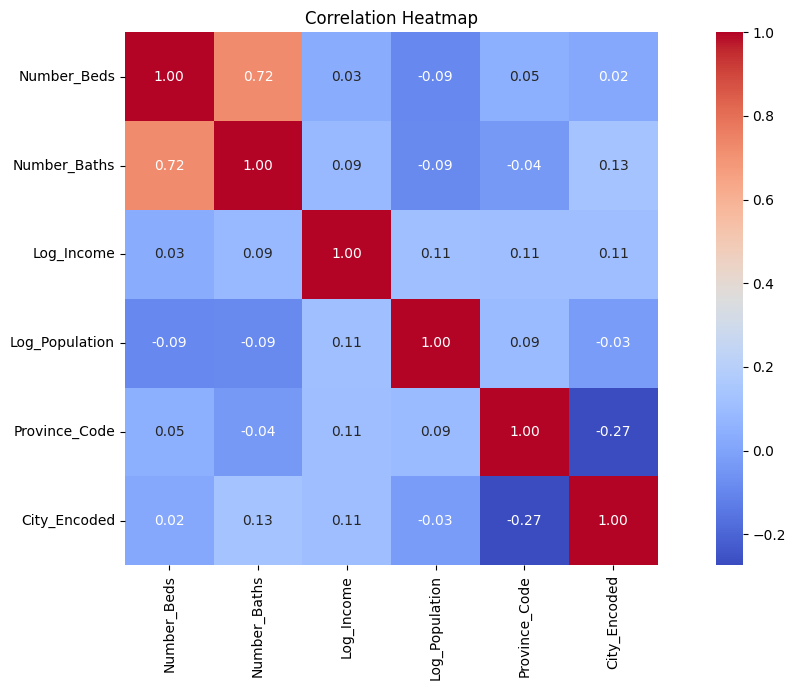

In [28]:
# ── Correlation Heatmap ─────────────────────────
corr_cols = ['Number_Beds', 'Number_Baths', 'Log_Income', 'Log_Population', 'Province_Code', 'City_Encoded']

plt.figure(figsize=(12, 7))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt=".2f",
            cmap="coolwarm", square=True)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("../plots/10_correlation_heatmap.png", dpi=150)
plt.show()

In [31]:
# ── Save featured dataset ─────────
featured_df = df[['Number_Beds', 'Number_Baths', 'Log_Income', 'Log_Population', 'Province_Code', 'City_Encoded', 'Log_Price']]

featured_df.to_csv("../dataset/processed/housing_featured.csv", index=False)
featured_df.shape

(27189, 7)